# CipherSpectrum TLS 1.3 End-to-End Workflow

This notebook is aligned with plans/plan_v1.txt and the full optimization plan v2. It integrates:

- **LDAM Loss + DRW**: Label-Distribution-Aware Margin Loss with Deferred Re-Weighting to handle long-tail feature distribution
- **LR Schedule**: Linear warmup → cosine annealing (replaces ReduceLROnPlateau)
- **Decoupled Weight Decay**: LayerNorm weights and biases are excluded from AdamW weight decay
- **NetMambaLite (SSM)**: Depthwise-conv + GLU gated architecture with optional adversarial debiasing
- **Adversarial Debiasing (GRL)**: Gradient Reversal Layer + Cipher Discriminator to produce cipher-agnostic representations
- **Occlusion experiments**: baseline, header_only, payload_only, length_only, size_agnostic (with IAT jitter)
- **Cross-cipher evaluation (Acc-Drop)**: Train on AES, test on ChaCha20
- **Mutual Information proxy** for shortcut learning detection
- Throughput and latency metrics
- Visualization: loss curves, confusion matrix, occlusion F1 curve, feature heatmap


In [2]:
from pathlib import Path
import sys
import json
import copy
import time
import importlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Robust project root discovery for notebook execution from different cwd values.
start = Path.cwd().resolve()
candidates = [start, *start.parents]
ROOT = None
for p in candidates:
    if (p / 'src' / 'cipherspectrum_tls13').exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError(f'Cannot locate project root from cwd={start}')

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Force-refresh local package modules to avoid stale class definitions in long-lived notebook kernels.
import cipherspectrum_tls13.settings as settings_mod
import cipherspectrum_tls13.train_eval as train_eval_mod
import cipherspectrum_tls13.dataset as dataset_mod
importlib.reload(settings_mod)
importlib.reload(dataset_mod)
importlib.reload(train_eval_mod)

load_config = settings_mod.load_config
train_one_run = train_eval_mod.train_one_run
cross_cipher_eval = train_eval_mod.cross_cipher_eval

print('Project ROOT:', ROOT)
print('Python:', sys.executable)
sns.set_theme(style='whitegrid')

Project ROOT: C:\Working\CipherSpectrum_TLS 1.3
Python: c:\Users\75778\.conda\envs\dl\python.exe


## 1) Environment Check (CUDA 12.8 Setup)

In [ ]:
import importlib.util
import platform
import torch

print('Platform:', platform.platform())
print('Current Python:', sys.executable)
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Triton installed:', importlib.util.find_spec('triton') is not None)
print('torch.compile available:', hasattr(torch, 'compile'))
if torch.cuda.is_available():
    print('CUDA device:', torch.cuda.get_device_name(0))
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM total: {vram_gb:.1f} GB')
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch, 'set_float32_matmul_precision'):
        torch.set_float32_matmul_precision('high')
    print('cudnn.benchmark: ON | TF32: ON | float32 matmul precision: high')
else:
    print('WARNING: CUDA not available, training will run on CPU')

Current Python: c:\Users\75778\.conda\envs\dl\python.exe
Expected Python: D:\Anaconda\envs\dl\python.exe
Python matched: False
Torch version: 2.11.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5090 Laptop GPU
VRAM total: 23.9 GB
cudnn.benchmark: ON | TF32: ON


## 1.1) Offline Feature Precompute (Recommended Before Training)

To remove runtime PCAP parsing bottlenecks, precompute features into `.pt` tensors once and reuse them in DataLoader.
Run the next code cell once before training/diagnostic cells.

In [4]:
from cipherspectrum_tls13.data_index import build_index, stratified_split
from cipherspectrum_tls13.dataset import FeatureParams
from cipherspectrum_tls13.precompute import precompute_features
import importlib
import cipherspectrum_tls13.settings as settings_mod

RUN_PREPROCESS = True
REBUILD_PREPROCESS_INDEX = False
OVERWRITE_PRECOMPUTED = False

if RUN_PREPROCESS:
    # Refresh settings module each run to avoid stale DataConfig signatures in notebook memory.
    importlib.reload(settings_mod)
    load_config = settings_mod.load_config

    pre_cfg = load_config(ROOT / 'configs' / 'default_experiment.yaml')
    pre_cfg.data.root_dir = str(ROOT / 'data')
    pre_cfg.output.output_dir = str(ROOT / 'outputs')

    # Keep precompute output run_name aligned with training cells.
    target_run_name = cfg.output.run_name if ('cfg' in globals()) else 'notebook_baseline_schemeA_10ep'
    pre_cfg.output.run_name = target_run_name

    # Keep precompute parameters aligned with training feature settings.
    fp = FeatureParams(
        max_packets=pre_cfg.data.max_packets,
        max_payload_bytes=pre_cfg.data.max_payload_bytes,
        mode=pre_cfg.features.mode,
        handshake_packets=pre_cfg.data.handshake_packets,
        randomization_std=pre_cfg.features.length_randomization_std,
    )

    run_out_dir = Path(pre_cfg.output.output_dir) / pre_cfg.output.run_name
    run_out_dir.mkdir(parents=True, exist_ok=True)
    precomputed_dir = Path(pre_cfg.data.precomputed_dir) if pre_cfg.data.precomputed_dir else (run_out_dir / 'precomputed_features')
    precomputed_index_path = run_out_dir / 'precomputed_index.csv'

    # Fast path: if index exists and all referenced .pt files exist, skip preprocessing entirely.
    can_skip = False
    if precomputed_index_path.exists() and (not REBUILD_PREPROCESS_INDEX):
        existing_df = pd.read_csv(precomputed_index_path)
        if ('pt_path' in existing_df.columns) and (len(existing_df) > 0):
            exists_mask = existing_df['pt_path'].map(lambda p: Path(p).exists())
            can_skip = bool(exists_mask.all())
            if can_skip:
                print('Precompute skipped: existing precomputed index and tensor files are complete.')
                print('run_name:', pre_cfg.output.run_name)
                print('rows:', len(existing_df))
                print('pt dir:', precomputed_dir)
                print('index:', precomputed_index_path)
                print('pt_path exists ratio:', float(exists_mask.mean()))

    if not can_skip:
        if (not precomputed_index_path.exists()) or REBUILD_PREPROCESS_INDEX:
            df_full = build_index(
                Path(pre_cfg.data.root_dir),
                pre_cfg.data.ciphers,
                pre_cfg.data.max_samples_per_domain_per_cipher,
            )
            df_split = stratified_split(
                df_full,
                train_ratio=pre_cfg.data.split.train,
                val_ratio=pre_cfg.data.split.val,
                test_ratio=pre_cfg.data.split.test,
                seed=pre_cfg.seed,
            )
        else:
            df_split = pd.read_csv(precomputed_index_path)

        pre_df = precompute_features(
            df_split,
            output_dir=precomputed_dir,
            feature_params=fp,
            overwrite=OVERWRITE_PRECOMPUTED,
            seed=pre_cfg.seed,
            index_out_path=precomputed_index_path,
        )

        print('Precompute finished.')
        print('run_name:', pre_cfg.output.run_name)
        print('rows:', len(pre_df))
        print('pt dir:', precomputed_dir)
        print('index:', precomputed_index_path)
        print('pt_path exists ratio:', float(pre_df['pt_path'].map(lambda p: Path(p).exists()).mean()))
else:
    print('Precompute skipped. Set RUN_PREPROCESS=True to run.')

Precompute skipped: existing precomputed index and tensor files are complete.
run_name: notebook_baseline_schemeA_10ep
rows: 123000
pt dir: C:\Working\CipherSpectrum_TLS 1.3\outputs\notebook_baseline_schemeA_10ep\precomputed_features
index: C:\Working\CipherSpectrum_TLS 1.3\outputs\notebook_baseline_schemeA_10ep\precomputed_index.csv
pt_path exists ratio: 1.0


## 2) Configure Baseline Training (Scheme A)
This section applies the selected stable baseline setup:
- Disable LDAM (`use_ldam=False`)
- Disable adversarial debiasing (`use_adversarial_debiasing=False`)
- Disable feature randomization (`length_randomization_std=0.0`)
- Use `batch_size=64`, `learning_rate=1e-3`
- Use `warmup_epochs=2` for multi-epoch training
- Run full training for `epochs=10`


## 2a) [Optional Later] Re-Enable Adversarial Debiasing (After Baseline Converges)
Do not enable GRL in the initial debugging phase. Turn it on only after the base classifier can fit cleanly.


In [5]:
# Optional cell for later-stage experiments only.
# Use this after baseline training is stable and convergent.


if 'cfg' not in globals():
    config_path = ROOT / 'configs' / 'default_experiment.yaml'
    cfg = load_config(config_path)
    cfg.data.root_dir = str(ROOT / 'data')
    cfg.output.output_dir = str(ROOT / 'outputs')
    print('cfg was not defined; initialized from default_experiment.yaml')

cfg.training.use_adversarial_debiasing = True
cfg.training.adversarial_lambda = 0.1
cfg.output.run_name = 'notebook_baseline_mamba_adv'
print('Adversarial debiasing ENABLED for later-stage fine-tuning. GRL lambda =', cfg.training.adversarial_lambda)
print('Adversarial debiasing:', cfg.training.use_adversarial_debiasing)

cfg was not defined; initialized from default_experiment.yaml
Adversarial debiasing ENABLED for later-stage fine-tuning. GRL lambda = 0.1
Adversarial debiasing: True


In [6]:
from pathlib import Path
import sys
import torch

# Make this cell runnable even when executed independently.
start = Path.cwd().resolve()
candidates = [start, *start.parents]
ROOT = None
for p in candidates:
    if (p / 'src' / 'cipherspectrum_tls13').exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError(f'Cannot locate project root from cwd={start}')

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from cipherspectrum_tls13.settings import load_config

config_path = ROOT / 'configs' / 'default_experiment.yaml'
cfg = load_config(config_path)

# Resolve runtime paths to absolute workspace paths.
cfg.data.root_dir = str(ROOT / 'data')
cfg.output.output_dir = str(ROOT / 'outputs')

cfg.output.run_name = 'notebook_baseline_schemeA_10ep'
cfg.features.mode = 'baseline'
cfg.training.model_name = 'mamba_lite'

# --- Scheme A baseline (selected) ---
cfg.features.length_randomization_std = 0.0
cfg.training.use_adversarial_debiasing = False
cfg.training.adversarial_lambda = 0.0
cfg.training.use_ldam = False

cfg.training.learning_rate = 1e-3
cfg.training.warmup_epochs = 2
cfg.training.min_learning_rate = 1e-6

cfg.training.weight_decay = 0.01
cfg.training.amp = False
cfg.training.batch_size = 64
cfg.training.epochs = 20
cfg.training.early_stop_patience = 5
cfg.training.gradient_clip_norm = 1.0
cfg.training.num_workers = 8

cfg.training.log_step_csv = True
cfg.training.live_plot = False
cfg.training.stop_on_non_finite = True
cfg.training.debug_input_stats_once = True

# --- Throughput-oriented data pipeline ---
cfg.data.use_precomputed_features = True
cfg.data.force_recompute_precomputed = False
cfg.data.preload_train = False
cfg.data.preload_val = True
cfg.data.preload_test = True
if not cfg.data.precomputed_dir:
    cfg.data.precomputed_dir = str(Path(cfg.output.output_dir) / cfg.output.run_name / 'precomputed_features')

device_str = 'cuda:' + str(torch.cuda.current_device()) if torch.cuda.is_available() else 'cpu'
print('Using config:', config_path)
print('Data root:', cfg.data.root_dir)
print('Output dir:', cfg.output.output_dir)
print('Data root exists:', Path(cfg.data.root_dir).exists())
print(f'Compute device: {device_str}')
print(f'Model: {cfg.training.model_name}')
print(f'LR: peak={cfg.training.learning_rate}, warmup={cfg.training.warmup_epochs}ep, min={cfg.training.min_learning_rate}')
print(f'LDAM enabled: {cfg.training.use_ldam}')
print(f'Adversarial debiasing: {cfg.training.use_adversarial_debiasing}')
print(f'AMP: {cfg.training.amp}, BatchSize: {cfg.training.batch_size}, Epochs: {cfg.training.epochs}')
print(f'length_randomization_std: {cfg.features.length_randomization_std}')
print('Run name:', cfg.output.run_name)
print('Precompute enabled:', cfg.data.use_precomputed_features)
print('Precompute dir:', cfg.data.precomputed_dir)
print('Preload (train/val/test):', cfg.data.preload_train, cfg.data.preload_val, cfg.data.preload_test)
cfg

Using config: C:\Working\CipherSpectrum_TLS 1.3\configs\default_experiment.yaml
Data root: C:\Working\CipherSpectrum_TLS 1.3\data
Output dir: C:\Working\CipherSpectrum_TLS 1.3\outputs
Data root exists: True
Compute device: cuda:0
Model: mamba_lite
LR: peak=0.001, warmup=2ep, min=1e-06
LDAM enabled: False
Adversarial debiasing: False
AMP: False, BatchSize: 64, Epochs: 20
length_randomization_std: 0.0
Run name: notebook_baseline_schemeA_10ep
Precompute enabled: True
Precompute dir: C:\Working\CipherSpectrum_TLS 1.3\outputs\notebook_baseline_schemeA_10ep\precomputed_features
Preload (train/val/test): False True True


ExperimentConfig(seed=42, data=DataConfig(root_dir='C:\\Working\\CipherSpectrum_TLS 1.3\\data', ciphers=['aes-128-gcm', 'aes-256-gcm', 'chacha20-poly1305'], train_ciphers=['aes-128-gcm', 'aes-256-gcm'], test_ciphers=['chacha20-poly1305'], max_samples_per_domain_per_cipher=1000, split=SplitConfig(train=0.7, val=0.15, test=0.15), max_packets=40, max_payload_bytes=784, handshake_packets=8, use_precomputed_features=True, precomputed_dir='C:\\Working\\CipherSpectrum_TLS 1.3\\outputs\\notebook_baseline_schemeA_10ep\\precomputed_features', force_recompute_precomputed=False, preload_train=False, preload_val=True, preload_test=True), features=FeatureConfig(mode='baseline', length_randomization_std=0.0), training=TrainingConfig(model_name='mamba_lite', batch_size=64, num_workers=8, epochs=20, learning_rate=0.001, weight_decay=0.01, amp=False, gradient_clip_norm=1.0, early_stop_patience=5, inference_amp=True, prefetch_factor=4, persistent_workers=True, non_blocking_transfers=True, compile_for_inf

## 3) Full Training Switch (Paused by Default During Diagnostics)

In [7]:
RUN_FULL_TRAINING = True

if RUN_FULL_TRAINING:
    start_t = time.time()
    # Force one-time index rebuild to avoid stale absolute paths in old CSV index files.
    train_metrics = train_one_run(cfg, force_index_rebuild=True)
    train_elapsed = time.time() - start_t

    run_dir = Path(cfg.output.output_dir) / cfg.output.run_name
    best_model_path = run_dir / 'best_model.pt'

    print('Train metrics:')
    print(json.dumps(train_metrics, indent=2))
    print('Elapsed (sec):', round(train_elapsed, 2))
    print('Checkpoint exists:', best_model_path.exists())
    print('Checkpoint path:', best_model_path)
else:
    print('Full training is paused. Set RUN_FULL_TRAINING=True to run.')

epoch:   0%|          | 0/20 [00:00<?, ?it/s]

[debug-input-stats] phase=train e1 x_seq[min,max]=(-1, 9.67036) x_bytes[min,max]=(0, 1) nan(seq,bytes)=(False, False) inf(seq,bytes)=(False, False)


epoch: 100%|██████████| 20/20 [05:03<00:00, 15.19s/it, eta_min=0.0, val_acc=0.9645, val_loss=0.0900]


Skipping torch.compile for inference: Triton is not installed in current environment.
Train metrics:
{
  "run_name": "notebook_baseline_schemeA_10ep",
  "feature_mode": "baseline",
  "model_name": "mamba_lite",
  "test_loss": 0.09774916975693392,
  "test_mutual_info_cipher_pred": 0.004296994584461513,
  "test_infer_samples_per_sec": 27891.0890011617,
  "elapsed_total_sec": 332.7607696999912,
  "accuracy": 0.9618428184281843,
  "macro_f1": 0.9569994923424441
}
Elapsed (sec): 333.29
Checkpoint exists: True
Checkpoint path: C:\Working\CipherSpectrum_TLS 1.3\outputs\notebook_baseline_schemeA_10ep\best_model.pt


## 3.1) Golden Rule Step 1: Overfit a Single Batch
Goal: verify the model can learn at all (forward, backward, labels, and loss wiring are healthy).

Protocol:
- Use exactly one mini-batch
- Disable feature randomization
- Disable adversarial debiasing
- Iterate this same batch for a few hundred steps
- Expect loss to approach 0 and accuracy to approach 100%


In [8]:
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader

from cipherspectrum_tls13.dataset import CipherSpectrumDataset, FeatureParams
from cipherspectrum_tls13.models import create_model
from cipherspectrum_tls13.train_eval import set_seed

set_seed(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

single_cfg = copy.deepcopy(cfg)
single_cfg.features.length_randomization_std = 0.0
single_cfg.training.use_adversarial_debiasing = False
single_cfg.training.adversarial_lambda = 0.0
single_cfg.training.use_ldam = False
single_cfg.training.amp = False
single_cfg.training.batch_size = 32
single_cfg.training.learning_rate = 1e-3

# Enforce precomputed path for this diagnostic cell.
single_cfg.data.use_precomputed_features = True
single_cfg.data.preload_train = True

print('Single-batch overfit setup:')
print('  batch_size =', single_cfg.training.batch_size)
print('  lr =', single_cfg.training.learning_rate)
print('  use_ldam =', single_cfg.training.use_ldam)
print('  adversarial_debiasing =', single_cfg.training.use_adversarial_debiasing)
print('  length_randomization_std =', single_cfg.features.length_randomization_std)

run_dir = Path(single_cfg.output.output_dir) / single_cfg.output.run_name
precomputed_index_path = run_dir / 'precomputed_index.csv'
if not precomputed_index_path.exists():
    raise FileNotFoundError(
        f'Precomputed index not found: {precomputed_index_path}. Run Cell 6 (Offline Feature Precompute) first.'
    )

split_df = pd.read_csv(precomputed_index_path)
train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)

fp = FeatureParams(
    max_packets=single_cfg.data.max_packets,
    max_payload_bytes=single_cfg.data.max_payload_bytes,
    mode=single_cfg.features.mode,
    handshake_packets=single_cfg.data.handshake_packets,
    randomization_std=single_cfg.features.length_randomization_std,
)
train_set = CipherSpectrumDataset(
    train_df,
    fp,
    seed=single_cfg.seed,
    preload=True,
    use_precomputed=True,
)

actual_bs = max(1, min(single_cfg.training.batch_size, len(train_set)))
one_batch_loader = DataLoader(
    train_set,
    batch_size=actual_bs,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

batch = next(iter(one_batch_loader))
x_seq = batch['x_seq'].to(device, non_blocking=True)
x_bytes = batch['x_bytes'].to(device, non_blocking=True)
y = batch['y'].to(device, non_blocking=True)

print('Single batch tensor stats before training:')
print('  x_seq min/max:', float(x_seq.min()), float(x_seq.max()))
print('  x_bytes min/max:', float(x_bytes.min()), float(x_bytes.max()))
print('  x_seq has NaN:', bool(torch.isnan(x_seq).any().item()))
print('  x_bytes has NaN:', bool(torch.isnan(x_bytes).any().item()))

num_classes = int(split_df['label'].max()) + 1
num_ciphers = len(split_df['cipher'].unique())
model = create_model(
    single_cfg.training.model_name,
    seq_dim=3,
    byte_dim=single_cfg.data.max_payload_bytes,
    num_classes=num_classes,
    num_ciphers=num_ciphers,
    use_adversarial_debiasing=False,
    adversarial_lambda=0.0,
 ).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=single_cfg.training.learning_rate, weight_decay=single_cfg.training.weight_decay)

steps = 300
log_steps = {1, 2, 5, 10, 20, 50, 100, 150, 200, 250, 300}
history = []

model.train()
for step in range(1, steps + 1):
    optimizer.zero_grad(set_to_none=True)
    out = model(x_seq, x_bytes)
    logits = out if not isinstance(out, tuple) else out[0]
    loss = criterion(logits, y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), single_cfg.training.gradient_clip_norm)
    optimizer.step()

    with torch.no_grad():
        pred = torch.argmax(logits, dim=1)
        acc = (pred == y).float().mean().item()
    history.append((step, float(loss.item()), float(acc)))

    if step in log_steps:
        print(f'step={step:3d} | loss={loss.item():.6f} | acc={acc:.4f}')

final_step, final_loss, final_acc = history[-1]
print('\nFinal single-batch result:')
print(f'  step={final_step}, loss={final_loss:.6f}, acc={final_acc:.4f}')
if final_acc > 0.98 and final_loss < 0.05:
    print('PASS: model can overfit one batch. Core learning pipeline is likely healthy.')
else:
    print('FAIL/WARN: one-batch overfit did not converge well. Increase steps or verify label/data path.')

Single-batch overfit setup:
  batch_size = 32
  lr = 0.001
  use_ldam = False
  adversarial_debiasing = False
  length_randomization_std = 0.0
Single batch tensor stats before training:
  x_seq min/max: -1.0 9.670356750488281
  x_bytes min/max: 0.0 1.0
  x_seq has NaN: False
  x_bytes has NaN: False
step=  1 | loss=3.763256 | acc=0.0625
step=  2 | loss=3.522078 | acc=0.2500
step=  5 | loss=3.115359 | acc=0.1250
step= 10 | loss=2.623605 | acc=0.1875
step= 20 | loss=2.033772 | acc=0.2812
step= 50 | loss=0.101579 | acc=1.0000
step=100 | loss=0.003381 | acc=1.0000
step=150 | loss=0.001027 | acc=1.0000
step=200 | loss=0.001208 | acc=1.0000
step=250 | loss=0.000396 | acc=1.0000
step=300 | loss=0.000091 | acc=1.0000

Final single-batch result:
  step=300, loss=0.000091, acc=1.0000
PASS: model can overfit one batch. Core learning pipeline is likely healthy.


## 3.2) Golden Rule Steps 2-4: One Short Diagnostic Run
This cell performs a short run to validate stability before full training:
- Step 2: keep adversarial debiasing disabled
- Step 3: use large batch size + lower LR + AMP off
- Step 4: print one-time input range/NaN stats in DataLoader loop (`debug_input_stats_once=True`)

Run only 1 epoch to collect signals quickly.

In [9]:
diag_cfg = copy.deepcopy(cfg)
diag_cfg.output.run_name = 'notebook_diag_one_epoch'

# Short debug run: disable unstable components first.
diag_cfg.training.use_adversarial_debiasing = False
diag_cfg.training.adversarial_lambda = 0.0
diag_cfg.training.use_ldam = False

# Keep effective LR for only-1-epoch diagnostics.
diag_cfg.training.warmup_epochs = 0
diag_cfg.training.learning_rate = 1e-3
diag_cfg.training.min_learning_rate = 1e-6

# Moderate batch improves signal while keeping updates responsive.
diag_cfg.training.batch_size = 64
diag_cfg.training.num_workers = 8
diag_cfg.training.amp = False

# Inspect min/max/nan in DataLoader loop once.
diag_cfg.training.debug_input_stats_once = True

# Keep this very short for diagnosis only.
diag_cfg.training.epochs = 1
diag_cfg.training.early_stop_patience = 1
diag_cfg.training.stop_on_non_finite = True
diag_cfg.features.length_randomization_std = 0.0

print('Running one-epoch diagnostic train...')
print('diag config:','bs=', diag_cfg.training.batch_size, 'lr=', diag_cfg.training.learning_rate,
      'warmup=', diag_cfg.training.warmup_epochs, 'use_ldam=', diag_cfg.training.use_ldam)
diag_metrics = train_one_run(diag_cfg, force_index_rebuild=False)

run_dir = Path(diag_cfg.output.output_dir) / diag_cfg.output.run_name
best_model_path = run_dir / 'best_model.pt'
history_path = run_dir / 'history.csv'
metrics_path = run_dir / 'metrics.json'
step_csv_path = run_dir / 'step_metrics.csv'

print('Diagnostic metrics:')
print(json.dumps(diag_metrics, indent=2))
print('Checkpoint exists:', best_model_path.exists())
print('History exists:', history_path.exists())
print('Metrics exists:', metrics_path.exists())
print('Step CSV exists:', step_csv_path.exists())

if step_csv_path.exists():
    step_df = pd.read_csv(step_csv_path)
    print('Step rows:', len(step_df))
    if 'non_finite_loss' in step_df.columns:
        print('Non-finite step count:', int(step_df['non_finite_loss'].sum()))
    if 'lr' in step_df.columns:
        print('LR min/max:', float(step_df['lr'].min()), float(step_df['lr'].max()))
    display(step_df.head(10))

Running one-epoch diagnostic train...
diag config: bs= 64 lr= 0.001 warmup= 0 use_ldam= False


epoch:   0%|          | 0/1 [00:00<?, ?it/s]


[debug-input-stats] phase=train e1 x_seq[min,max]=(-1, 9.67036) x_bytes[min,max]=(0, 1) nan(seq,bytes)=(False, False) inf(seq,bytes)=(False, False)


epoch: 100%|██████████| 1/1 [00:23<00:00, 23.92s/it, eta_min=0.0, val_acc=0.0324, val_loss=3.7405]


Skipping torch.compile for inference: Triton is not installed in current environment.
Diagnostic metrics:
{
  "run_name": "notebook_diag_one_epoch",
  "feature_mode": "baseline",
  "model_name": "mamba_lite",
  "test_loss": 3.7410487047941214,
  "test_mutual_info_cipher_pred": 0.00016426234364227878,
  "test_infer_samples_per_sec": 27886.620407969272,
  "elapsed_total_sec": 51.11892500001704,
  "accuracy": 0.02997289972899729,
  "macro_f1": 0.0034690693024189635
}
Checkpoint exists: True
History exists: True
Metrics exists: True
Step CSV exists: True
Step rows: 1635
Non-finite step count: 0
LR min/max: 1e-07 1e-07


,global_step,epoch,phase,batch,loss,lr,elapsed_sec,non_finite_loss
0,0,1,train e1,1,3.760281,1.000000e-07,10.627008,0
1,1,1,train e1,2,3.773412,1.000000e-07,10.643077,0
2,2,1,train e1,3,3.738222,1.000000e-07,10.658642,0
3,3,1,train e1,4,3.741145,1.000000e-07,10.674585,0
4,4,1,train e1,5,3.761720,1.000000e-07,10.689650,0
5,5,1,train e1,6,3.746742,1.000000e-07,10.703745,0
6,6,1,train e1,7,3.722847,1.000000e-07,10.717527,0
7,7,1,train e1,8,3.758393,1.000000e-07,10.731350,0
8,8,1,train e1,9,3.759260,1.000000e-07,10.747174,0
9,9,1,train e1,10,3.710914,1.000000e-07,10.761384,0


## 4) Cross-Cipher Evaluation and Acc-Drop (AES -> ChaCha20)

In [10]:
if 'best_model_path' not in globals() or not Path(best_model_path).exists():
    print('No checkpoint found in current session. Run diagnostic/full training cell first.')
else:
    cross_cfg = copy.deepcopy(cfg)
    cross_cfg.output.run_name = 'notebook_cross_cipher_transformer'

    # Explicitly enforce precomputed-path evaluation in cross-cipher test.
    cross_cfg.data.use_precomputed_features = True
    cross_cfg.data.force_recompute_precomputed = False
    cross_cfg.data.preload_test = True
    if not cross_cfg.data.precomputed_dir:
        cross_cfg.data.precomputed_dir = str(Path(cfg.output.output_dir) / cfg.output.run_name / 'precomputed_features')

    print('Cross-cipher eval precompute enabled:', cross_cfg.data.use_precomputed_features)
    print('Cross-cipher preload_test:', cross_cfg.data.preload_test)
    print('Cross-cipher precompute dir:', cross_cfg.data.precomputed_dir)

    cross_result = cross_cipher_eval(cross_cfg, best_model_path)
    base_acc = None
    if 'train_metrics' in globals() and isinstance(train_metrics, dict):
        base_acc = train_metrics.get('accuracy')
    elif 'diag_metrics' in globals() and isinstance(diag_metrics, dict):
        base_acc = diag_metrics.get('accuracy')

    print('Cross-cipher metrics:')
    print(json.dumps(cross_result, indent=2))
    if base_acc is not None:
        acc_drop = base_acc - cross_result['accuracy']
        print('Acc-Drop vs current in-cipher metric:', round(acc_drop, 6))
    else:
        print('Acc-Drop unavailable: no in-cipher accuracy found in session.')

precompute: 100%|██████████| 41000/41000 [00:05<00:00, 7821.24it/s]


Skipping torch.compile for inference: Triton is not installed in current environment.
[debug-input-stats] phase=cross-cipher-test x_seq[min,max]=(-1, 9.91151) x_bytes[min,max]=(0, 1) nan(seq,bytes)=(False, False) inf(seq,bytes)=(False, False)
Cross-cipher metrics:
{
  "run_name": "notebook_cross_cipher_transformer",
  "feature_mode": "baseline",
  "model_name": "mamba_lite",
  "test_loss": 3.7391050817813962,
  "test_mutual_info_cipher_pred": 0.0,
  "test_infer_samples_per_sec": 642.347139707241,
  "elapsed_eval_sec": 80.74732980001136,
  "accuracy": 0.030634146341463414,
  "macro_f1": 0.0033990927482574988,
  "train_ciphers": [
    "aes-128-gcm",
    "aes-256-gcm"
  ],
  "test_ciphers": [
    "chacha20-poly1305"
  ]
}
Acc-Drop vs current in-cipher metric: 0.931209


## 5) Visualization: Curves, Confusion Matrix, and Key Metrics

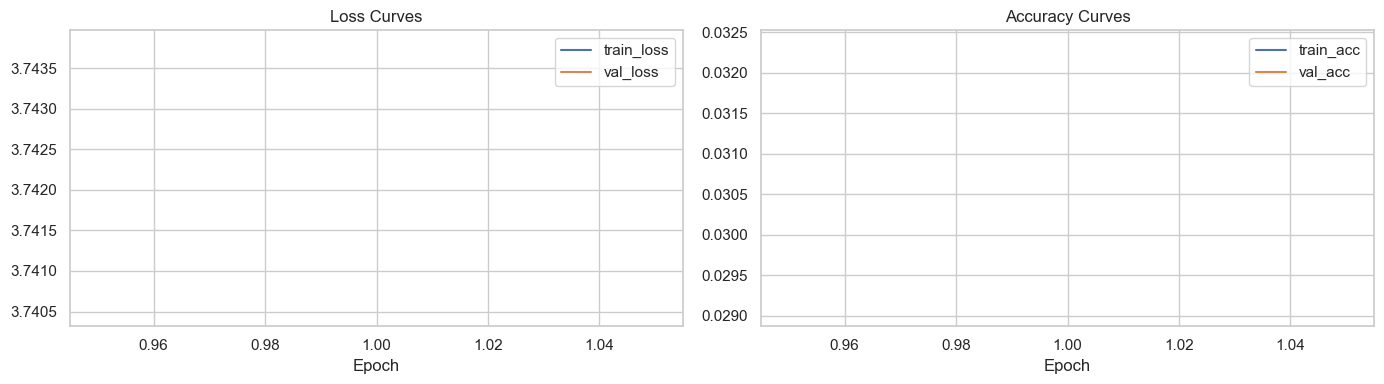

Test metrics summary:
{
  "run_name": "notebook_diag_one_epoch",
  "feature_mode": "baseline",
  "model_name": "mamba_lite",
  "test_loss": 3.7410487047941214,
  "test_mutual_info_cipher_pred": 0.00016426234364227878,
  "test_infer_samples_per_sec": 27886.620407969272,
  "elapsed_total_sec": 51.11892500001704,
  "accuracy": 0.02997289972899729,
  "macro_f1": 0.0034690693024189635
}
Classification report keys: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Confusion matrix saved at: C:\Working\CipherSpectrum_TLS 1.3\outputs\notebook_diag_one_epoch\confusion_matrix.png


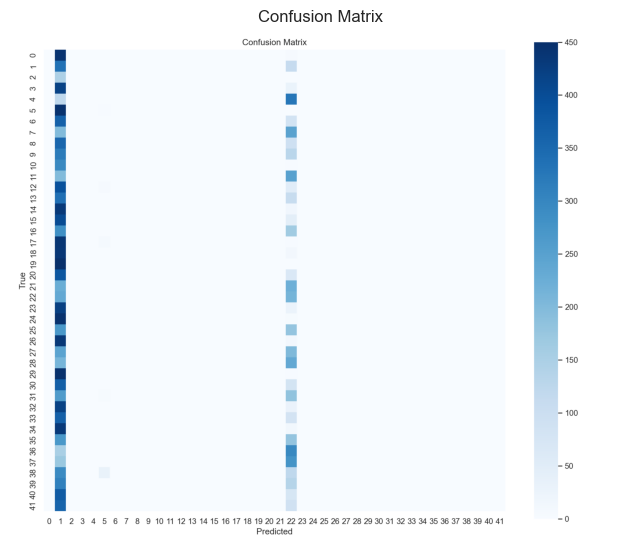

In [11]:
history_path = run_dir / 'history.csv'
metrics_path = run_dir / 'metrics.json'
report_path = run_dir / 'classification_report.json'
cm_path = run_dir / 'confusion_matrix.png'

history_df = pd.read_csv(history_path)
with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics = json.load(f)
with open(report_path, 'r', encoding='utf-8') as f:
    report = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train_loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val_loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_acc'], label='train_acc')
axes[1].plot(history_df['epoch'], history_df['val_acc'], label='val_acc')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Test metrics summary:')
print(json.dumps(metrics, indent=2))
print('Classification report keys:', list(report.keys())[:10])
print('Confusion matrix saved at:', cm_path)

if cm_path.exists():
    import matplotlib.image as mpimg
    img = mpimg.imread(cm_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix')
    plt.show()

## 6) Full Plan Matrix: G1–G6 + Model Comparison + Occlusion Curve

Runs all experimental groups:
- **G1 Baseline**: full features (seq + payload bytes + IAT)
- **G2 Header-Only**: handshake packets only, no payload bytes
- **G3 Payload-Only**: post-handshake packets, evaluates whether AEAD ciphertext leaks learnable patterns
- **G4 Length-Only**: only packet length sequences, payload zeroed
- **G5 Size-Agnostic**: aggressive length + IAT jitter (removes AES block-padding and timing fingerprints)
- **G6 Cross-Cipher**: train on AES, test on ChaCha20 — measures Acc-Drop (algorithm bias)

Each group runs with `mamba_lite` (primary) and optionally `transformer` (baseline comparison).


In [12]:
GROUPS = {
    'G1_baseline':     {'feature_mode': 'baseline',     'cross_cipher': False},
    'G2_header_only':  {'feature_mode': 'header_only',  'cross_cipher': False},
    'G3_payload_only': {'feature_mode': 'payload_only', 'cross_cipher': False},
    'G4_length_only':  {'feature_mode': 'length_only',  'cross_cipher': False},
    'G5_size_agnostic':{'feature_mode': 'size_agnostic','cross_cipher': False},
    'G6_cross_cipher': {'feature_mode': 'baseline',     'cross_cipher': True},
}

# Keep NetMambaLite as the primary architecture for all groups.
models_to_run = ['mamba_lite']
# models_to_run = ['mamba_lite', 'transformer']

config_path = ROOT / 'configs' / 'default_experiment.yaml'
base = load_config(config_path)
base.data.root_dir = str(ROOT / 'data')
base.output.output_dir = str(ROOT / 'outputs')

# --- Stable baseline hyperparameters ---
base.training.model_name = 'mamba_lite'
base.training.learning_rate = 1e-3
base.training.warmup_epochs = 2
base.training.min_learning_rate = 1e-6
base.training.use_ldam = False
base.training.weight_decay = 0.01
base.training.use_adversarial_debiasing = False
base.training.adversarial_lambda = 0.0
base.training.batch_size = 64
base.training.epochs = 20
base.training.early_stop_patience = 5
base.training.gradient_clip_norm = 1.0
base.training.amp = False
base.training.num_workers = 8
base.training.log_step_csv = True
base.training.live_plot = False
base.training.stop_on_non_finite = False
base.features.length_randomization_std = 0.0

# --- Force preprocessing path for all matrix runs ---
base.data.use_precomputed_features = True
base.data.force_recompute_precomputed = False
base.data.preload_train = False
base.data.preload_val = True
base.data.preload_test = True

results = []

for model_name in models_to_run:
    for group_name, spec in GROUPS.items():
        cfg_i = copy.deepcopy(base)
        cfg_i.training.model_name = model_name
        cfg_i.features.mode = spec['feature_mode']
        cfg_i.output.run_name = f'notebook_{group_name}_{model_name}'

        if not cfg_i.data.precomputed_dir:
            cfg_i.data.precomputed_dir = str(Path(cfg_i.output.output_dir) / cfg_i.output.run_name / 'precomputed_features')

        print(f'=== {group_name} | {model_name} | mode={spec["feature_mode"]} ===')
        print('precompute enabled:', cfg_i.data.use_precomputed_features, '| preload test:', cfg_i.data.preload_test)
        in_cipher = train_one_run(cfg_i, force_index_rebuild=False)
        in_cipher['group'] = group_name
        in_cipher['metric_type'] = 'in_cipher'
        results.append(in_cipher)

        if spec['cross_cipher']:
            ckpt = Path(cfg_i.output.output_dir) / cfg_i.output.run_name / 'best_model.pt'
            cross_cfg = copy.deepcopy(cfg_i)
            cross_cfg.output.run_name = f'notebook_{group_name}_{model_name}_cross'
            cross = cross_cipher_eval(cross_cfg, ckpt)
            cross['group'] = group_name
            cross['metric_type'] = 'cross_cipher'
            cross['acc_drop_vs_in_cipher'] = in_cipher['accuracy'] - cross['accuracy']
            results.append(cross)

results_df = pd.DataFrame(results)
out_csv = Path(base.output.output_dir) / 'notebook_experiment_matrix_results.csv'
results_df.to_csv(out_csv, index=False)
print('Results saved to:', out_csv)
results_df


=== G1_baseline | mamba_lite | mode=baseline ===


epoch: 100%|██████████| 20/20 [05:39<00:00, 16.97s/it, eta_min=0.0, val_acc=0.9645, val_loss=0.0900]


Skipping torch.compile for inference: Triton is not installed in current environment.
=== G2_header_only | mamba_lite | mode=header_only ===


epoch: 100%|██████████| 20/20 [05:14<00:00, 15.71s/it, eta_min=0.0, val_acc=0.4379, val_loss=1.6346]


Skipping torch.compile for inference: Triton is not installed in current environment.
=== G3_payload_only | mamba_lite | mode=payload_only ===


...

epoch: 100%|██████████| 20/20 [05:15<00:00, 15.77s/it, eta_min=0.0, val_acc=0.9645, val_loss=0.0900]


Skipping torch.compile for inference: Triton is not installed in current environment.


precompute: 100%|██████████| 41000/41000 [01:13<00:00, 558.57it/s]


Skipping torch.compile for inference: Triton is not installed in current environment.
Results saved to: C:\Working\CipherSpectrum_TLS 1.3\outputs\notebook_experiment_matrix_results.csv


,run_name,feature_mode,model_name,test_loss,test_mutual_info_cipher_pred,test_infer_samples_per_sec,elapsed_total_sec,accuracy,macro_f1,group,metric_type,elapsed_eval_sec,train_ciphers,test_ciphers,acc_drop_vs_in_cipher
0,notebook_G1_baseline_mamba_lite,baseline,mamba_lite,0.097749,0.004297,27269.808819,565.450611,0.961843,0.956999,G1_baseline,in_cipher,NaN,NaN,NaN,NaN
1,notebook_G2_header_only_mamba_lite,header_only,mamba_lite,1.665192,0.011393,24268.147642,542.771937,0.431003,0.405543,G2_header_only,in_cipher,NaN,NaN,NaN,NaN
2,notebook_G3_payload_only_mamba_lite,payload_only,mamba_lite,0.115318,0.004400,27395.588287,546.922839,0.956802,0.951785,G3_payload_only,in_cipher,NaN,NaN,NaN,NaN
3,notebook_G4_length_only_mamba_lite,length_only,mamba_lite,0.257660,0.002698,26951.933528,525.419191,0.895718,0.880191,G4_length_only,in_cipher,NaN,NaN,NaN,NaN
4,notebook_G5_size_agnostic_mamba_lite,size_agnostic,mamba_lite,0.204334,0.001379,26833.026584,525.202637,0.914092,0.897773,G5_size_agnostic,in_cipher,NaN,NaN,NaN,NaN
5,notebook_G6_cross_cipher_mamba_lite,baseline,mamba_lite,0.097749,0.004297,27293.614049,545.394849,0.961843,0.956999,G6_cross_cipher,in_cipher,NaN,NaN,NaN,NaN
6,notebook_G6_cross_cipher_mamba_lite_cross,baseline,mamba_lite,0.061220,0.000000,508.989004,NaN,0.975927,0.952971,G6_cross_cipher,cross_cipher,165.379676,"[aes-128-gcm, aes-256-gcm]",[chacha20-poly1305],-0.014084


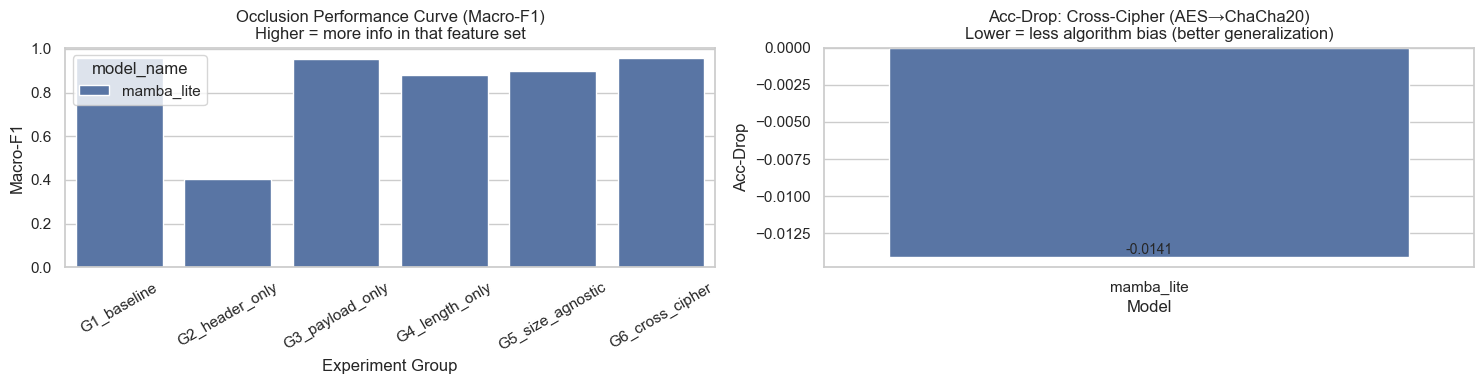

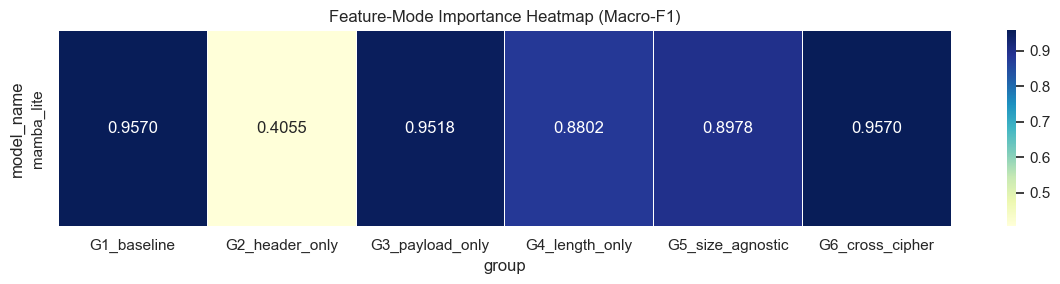


Full summary table:


,group,model_name,metric_type,accuracy,macro_f1,test_mutual_info_cipher_pred,test_infer_samples_per_sec,acc_drop_vs_in_cipher
0,G1_baseline,mamba_lite,in_cipher,0.961843,0.956999,0.004297,27269.808819,NaN
1,G2_header_only,mamba_lite,in_cipher,0.431003,0.405543,0.011393,24268.147642,NaN
2,G3_payload_only,mamba_lite,in_cipher,0.956802,0.951785,0.004400,27395.588287,NaN
3,G4_length_only,mamba_lite,in_cipher,0.895718,0.880191,0.002698,26951.933528,NaN
4,G5_size_agnostic,mamba_lite,in_cipher,0.914092,0.897773,0.001379,26833.026584,NaN
6,G6_cross_cipher,mamba_lite,cross_cipher,0.975927,0.952971,0.000000,508.989004,-0.014084
5,G6_cross_cipher,mamba_lite,in_cipher,0.961843,0.956999,0.004297,27293.614049,NaN


In [13]:
# --- Visualization: Occlusion F1 curve, Acc-Drop bar, Feature Heatmap ---

in_cipher_df = results_df[results_df['metric_type'] == 'in_cipher'].copy()
cross_df = results_df[results_df['metric_type'] == 'cross_cipher'].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Occlusion performance curve
if not in_cipher_df.empty:
    sns.barplot(data=in_cipher_df, x='group', y='macro_f1', hue='model_name', ax=axes[0])
    axes[0].set_title('Occlusion Performance Curve (Macro-F1)\nHigher = more info in that feature set')
    axes[0].set_xlabel('Experiment Group')
    axes[0].set_ylabel('Macro-F1')
    axes[0].tick_params(axis='x', rotation=30)

# Acc-Drop bar (cross-cipher bias metric)
if not cross_df.empty and 'acc_drop_vs_in_cipher' in cross_df.columns:
    sns.barplot(data=cross_df, x='model_name', y='acc_drop_vs_in_cipher', ax=axes[1])
    axes[1].set_title('Acc-Drop: Cross-Cipher (AES→ChaCha20)\nLower = less algorithm bias (better generalization)')
    axes[1].set_xlabel('Model')
    axes[1].set_ylabel('Acc-Drop')
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Feature-mode importance heatmap
if not in_cipher_df.empty:
    pivot = in_cipher_df.pivot_table(index='model_name', columns='group', values='macro_f1', aggfunc='mean')
    plt.figure(figsize=(12, max(3, len(pivot) * 1.5)))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5)
    plt.title('Feature-Mode Importance Heatmap (Macro-F1)')
    plt.tight_layout()
    plt.show()

# Summary table
cols_to_show = [c for c in [
    'group', 'model_name', 'metric_type', 'accuracy', 'macro_f1',
    'test_mutual_info_cipher_pred', 'test_infer_samples_per_sec',
    'acc_drop_vs_in_cipher',
] if c in results_df.columns]

print('\nFull summary table:')
results_df[cols_to_show].sort_values(['model_name', 'group', 'metric_type'])


## 7) Shortcut Learning Diagnosis: Mutual Information (MI) vs Acc-Drop

`test_mutual_info_cipher_pred` measures how much the model's predictions correlate with the cipher type (AES vs ChaCha20).  
Higher MI → model has learned cipher-specific shortcuts.  
Combined with the Acc-Drop from G6, this quantifies algorithm bias.


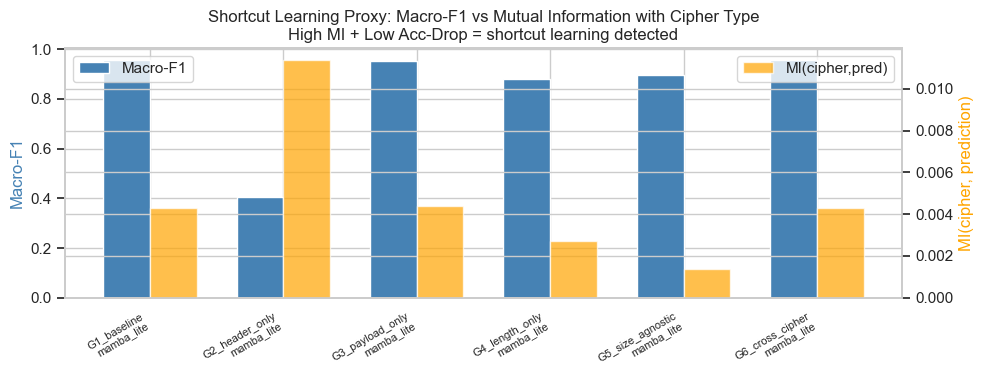


MI / F1 Summary:
           group model_name  accuracy  macro_f1  MI(cipher,pred)
     G1_baseline mamba_lite  0.961843  0.956999         0.004297
  G2_header_only mamba_lite  0.431003  0.405543         0.011393
 G3_payload_only mamba_lite  0.956802  0.951785         0.004400
  G4_length_only mamba_lite  0.895718  0.880191         0.002698
G5_size_agnostic mamba_lite  0.914092  0.897773         0.001379
 G6_cross_cipher mamba_lite  0.961843  0.956999         0.004297

Cross-cipher Acc-Drop:
          group model_name  accuracy  macro_f1  acc_drop_vs_in_cipher
G6_cross_cipher mamba_lite  0.975927  0.952971              -0.014084


In [14]:
import numpy as np

if 'results_df' in dir() and not results_df.empty and 'test_mutual_info_cipher_pred' in results_df.columns:
    mi_df = results_df[results_df['metric_type'] == 'in_cipher'][
        ['group', 'model_name', 'accuracy', 'macro_f1', 'test_mutual_info_cipher_pred']
    ].copy()
    mi_df = mi_df.rename(columns={'test_mutual_info_cipher_pred': 'MI(cipher,pred)'})

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(mi_df))
    width = 0.35
    bars1 = ax.bar(x - width/2, mi_df['macro_f1'], width, label='Macro-F1', color='steelblue')
    ax2 = ax.twinx()
    bars2 = ax2.bar(x + width/2, mi_df['MI(cipher,pred)'], width, label='MI(cipher,pred)', color='orange', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['group']}\n{r['model_name']}" for _, r in mi_df.iterrows()],
        rotation=30, ha='right', fontsize=8
    )
    ax.set_ylabel('Macro-F1', color='steelblue')
    ax2.set_ylabel('MI(cipher, prediction)', color='orange')
    ax.set_title('Shortcut Learning Proxy: Macro-F1 vs Mutual Information with Cipher Type\n'
                 'High MI + Low Acc-Drop = shortcut learning detected')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    print('\nMI / F1 Summary:')
    print(mi_df.to_string(index=False))

    if 'acc_drop_vs_in_cipher' in results_df.columns:
        drop_df = results_df[results_df['metric_type'] == 'cross_cipher'][
            ['group', 'model_name', 'accuracy', 'macro_f1', 'acc_drop_vs_in_cipher']
        ]
        if not drop_df.empty:
            print('\nCross-cipher Acc-Drop:')
            print(drop_df.to_string(index=False))
else:
    print('Run the experiment matrix cell (Section 6) first to generate results_df.')
